In [1]:
!pip install langchain-openai langchain_ollama pydantic typeddict langgraph ipython python-dotenv

^C


### Prompt Chaining con Decision Gateway
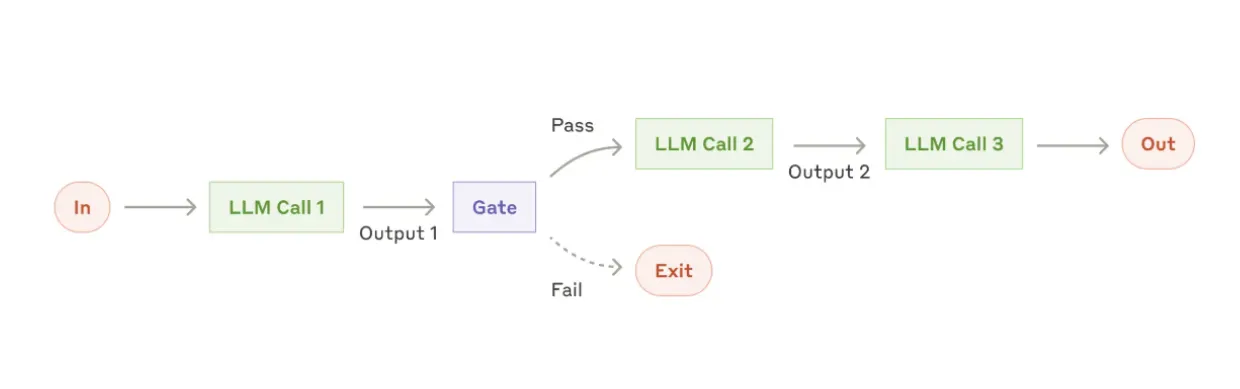

In [10]:
from langchain_openai import ChatOpenAI # Establece la conexión con el modelo de lenguaje de OpenAI
from langchain_ollama import ChatOllama # Establece la conexión con el modelo de lenguaje de Ollama
from dotenv import load_dotenv # Cargamos variables de entorno (OpenAI Key, LangSmith Proj)
load_dotenv()
import os
OPENAI_MODEL = os.getenv("OPENAI_MODEL")
llm = ChatOpenAI(model=OPENAI_MODEL, temperature=0.2)
#llm = ChatOllama(model="llama3.2:latest", temperature=0.2)

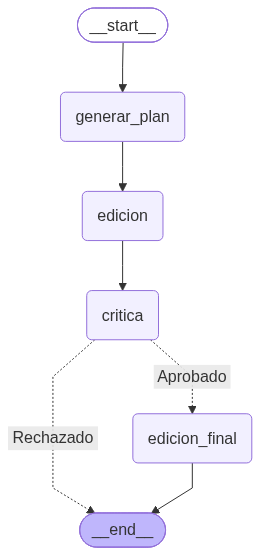

In [11]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
import json

# Define el State de mi Graph para la edicion
class State(TypedDict):
    libro: str
    plan: str
    edicion: str
    critica: str
    edicion_final: str

# Contruyendo los nodos del grafo
def generar_plan(state: State):
    """Primera llamada al LLM para generar el plan de edicion"""

    msg = llm.invoke(f"""Dada la tarea de escribir un parrafo emocionante del libro {state['libro']} , 
                     debes resolver el crear un plan de ideacion que oriente su escritura""")
    return {"plan": msg.content}


def edicion(state: State):
    """Segunda invocacion al LLM que toma el plan de edicion para ya escribirlo"""
    msg = llm.invoke(f"""Ejecuta el plan de ideacion {state['plan']} al escribir el parrafo emocionante""")
    return {"edicion": msg.content}

def critica(state: State):
    """Tercera invocacion al LLM que ahora toma el rol de critico"""
    # Check simple si va asociada a la pelea con aji seco
    msg = llm.invoke(f"""Asume el rol de critico y valida si es que menciona al personaje principal del libro.
                        Finalmente, da un feedback constructivo hacia el parrafo creado.
                     Aqui el parrafo: {state["edicion"]}""")
    return {"critica": msg.content}

def validar_critica(state: State):
    """Funcion de compuerta que determina una buena o mala edicion del parrafo"""
    if "carmelo" in state["critica"].lower():
            return "Aprobado"
    return "Rechazado"


def edicion_final(state: State):
    """Cuarta invocacion a LLM que mejora el parrafo"""
    msg = llm.invoke(f"Agrega un cambio sorprendente al parrafo {state["edicion"]} en base a: {state['critica']}")
    return {"edicion_final": msg.content}


# Construye un workflow
workflow = StateGraph(State)

# Agrega nodos
workflow.add_node("generar_plan", generar_plan)
workflow.add_node("edicion", edicion)
workflow.add_node("critica", critica)
workflow.add_node("edicion_final", edicion_final)

# Conecta nodos usando vertices
workflow.add_edge(START, "generar_plan")
workflow.add_edge("generar_plan", "edicion")
workflow.add_edge("edicion", "critica")
workflow.add_conditional_edges(
    "critica", validar_critica, {"Aprobado": "edicion_final", "Rechazado": END}
)
workflow.add_edge("edicion_final", END)

# Compilar
chain = workflow.compile()

# Mostrar Workflow
display(Image(chain.get_graph().draw_mermaid_png()))

In [13]:
#Esta invocacion puede pasar un estado inicial variable.
state = chain.invoke({"libro": "Caballero Carmelo de Abraham Valdelomar"}) 

In [6]:
print("generar plan:")
print(state["plan"])
print("\n########### Edicion ###########\n")
print(state["edicion"])
print("\n########### Critica ###########n")
print(state["critica"])

if "carmelo" in state["critica"].lower():
    print("\n########### Edicion final ###########n")
    print(state["edicion_final"])
else:
    print("Parrafo rechazado! no se menciona la batalla con aji seco")

generar plan:
¡Claro! Aquí te presento un plan de idea para escribir un párrafo emocionante del libro "Caballero Carmelo" de Abraham Valdelomar:

**Título:** "La Lucha por la Justicia"

**Objetivo:** Crear un párrafo que capture la esencia emocional y la intensidad de la lucha entre el caballero Carmelo y su enemigo, el malvado lord.

**Ideas clave:**

1. **Introducción**: Comienzo con una descripción del escenario donde se desarrolla la batalla, enfatizando la tensión y la anticipación.
2. **Desarrollo**: Describo la lucha intensa entre Carmelo y el lord, destacando las habilidades y fuerzas de cada personaje.
3. **Emoción**: Incluyo detalles que transmitan la emoción y la pasión de la lucha, como gritos, golpes y movimientos agresivos.
4. **Climax**: Destaco el momento más intenso de la batalla, donde Carmelo enfrenta su máximo desafío.

**Estructura:**

1. Introducción (2-3 oraciones)
 * "En el corazón del castillo, la lucha entre el caballero Carmelo y el malvado lord se intensific

### Paralelizacion
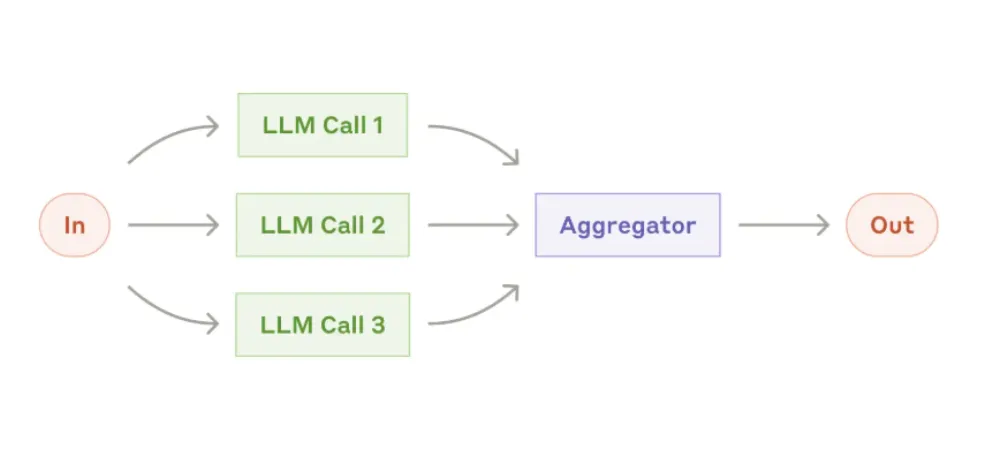

 - Util cuando tenemos mas de una perspectiva de una solucion
 - Util cuando podemos poner tareas en paralelo
 - Util cuando tenemos mas de una consulta de RAG en paralelo --> Multi query RAG


In [14]:
class State(TypedDict):
    libro: str
    animal: str
    femenino: str
    masculino: str
    composicion: str


def genera_animal(state: State):
    "Genera un nuevo personaje animal en base al libro indicado"
    msg = llm.invoke(f"Imagina un nuevo personaje que sea un animal en base al libro {state["libro"]}")
    return {"animal": msg.content}

def genera_femenino(state: State):
    "Genera un nuevo personaje humano femenino en base al libro indicado"
    msg = llm.invoke(f"Imagina un nuevo personaje humano, femenino, en base al libro {state["libro"]}")
    return {"femenino": msg.content}

def genera_masculino(state: State):
    "Genera un nuevo personaje humano masculino en base al libro indicado"
    msg = llm.invoke(f"Imagina un nuevo personaje humano, masculino, en base al libro {state["libro"]}")
    return {"masculino": msg.content}

def genera_composicion(state: State):
    msg = llm.invoke(f"""En base a estos nuevos personajes generados basados en el libro {state["libro"]},
    crea una nueva composicion de una trama con esos personajes. Aqui el detalle de cada personaje:\n
    PERSONAJE ANIMAL: {state["animal"]}\n
    PERSONAJE FEMENINO HUMANO: {state["animal"]}\n
    PERSONAJE MASCULINO HUMANO: {state["animal"]}
    """)
    return {"composicion": msg.content}


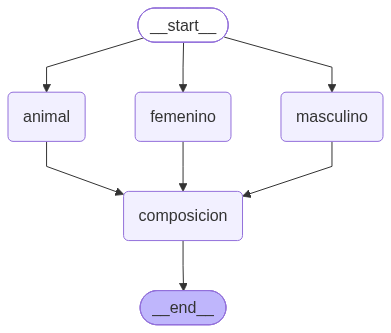

In [15]:
# Construye un workflow
parallelworkflowBuilder = StateGraph(State)

# Agrega nodos
parallelworkflowBuilder.add_node("animal", genera_animal)
parallelworkflowBuilder.add_node("femenino", genera_femenino)
parallelworkflowBuilder.add_node("masculino", genera_masculino)
parallelworkflowBuilder.add_node("composicion", genera_composicion)

# Conecta nodos usando vertices
parallelworkflowBuilder.add_edge(START, "animal")
parallelworkflowBuilder.add_edge(START, "femenino")
parallelworkflowBuilder.add_edge(START, "masculino")
parallelworkflowBuilder.add_edge("animal", "composicion")
parallelworkflowBuilder.add_edge("femenino", "composicion")
parallelworkflowBuilder.add_edge("masculino", "composicion")
parallelworkflowBuilder.add_edge("composicion", END)

# Compilar
parallelChain = parallelworkflowBuilder.compile()

# Mostrar Workflow
display(Image(parallelChain.get_graph().draw_mermaid_png()))

In [16]:
state = parallelChain.invoke({"libro":"el caballero carmelo de abraham valdelomar"})
print(state["composicion"])

**Título: La Aventura de la Princesa Lila y el Caballero de los Sueños**

**Trama:**

En un hermoso valle rodeado de majestuosas montañas, vive la Princesa Lila, una llama de pelaje lila brillante y un corazón lleno de sueños. Desde pequeña, Lila ha escuchado historias sobre el valiente Caballero Carmelo, un héroe que defendía a los débiles y luchaba por la justicia. Inspirada por sus hazañas, Lila decide que es hora de emprender su propia aventura y descubrir el mundo más allá de su hogar.

Un día, mientras pasea por los campos, Lila se encuentra con un grupo de animales que están preocupados por la llegada de un misterioso ser que ha estado causando estragos en el valle. Este ser, conocido como el Sombra, es un espíritu travieso que roba la alegría de los animales, sumiéndolos en la tristeza. Lila, con su espíritu valiente y su deseo de ayudar, decide que debe enfrentarse a este desafío.

En su travesía, Lila se encuentra con un joven llamado Mateo, un soñador que ha estado buscando 

### Routing
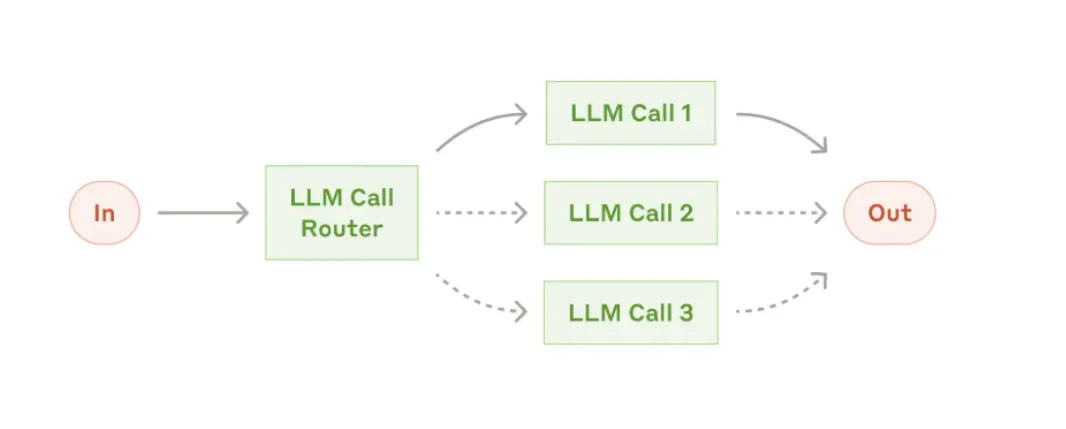
El enrutamiento clasifica una entrada y la dirige a una tarea de seguimiento especializada.

- Por ejemplo, al enrutar una pregunta a diferentes sistemas de recuperación.

Ejemplo:

- Enrutar una entrada entre chiste, cuento y poema.

In [17]:
from typing_extensions import Literal
from pydantic import BaseModel, Field

class Route(BaseModel):
    step: Literal["parrafo", "poema", "cancion"] = Field(
        None, description="El siguiente paso en el proceso de enrutamiento"
    )

router = llm.with_structured_output(Route)

In [18]:
# State
class State(TypedDict):
    input: str
    decision: str
    output: str

In [20]:
from langchain_core.messages import HumanMessage, SystemMessage

def genera_parrafo(state: State):
    """Escribe un parrafo creativo"""
    print("Escribe un parrafo creativo")
    result = llm.invoke(state["input"])
    return {"output": result.content}


def genera_poema(state: State):
    """Escribe un poema"""
    print("Escribe un poema")
    result = llm.invoke(state["input"])
    return {"output": result.content}


def genera_cancion(state: State):
    """Escribe la letra de una cancion"""
    print("Escribe la letra de una cancion")
    result = llm.invoke(state["input"])
    return {"output": result.content}


def enrutador(state: State):
    """Enrutar el input hacia el nodo apropiado"""
    # correr el LLM con salida estructurada para enrutar la atencion
    decision = router.invoke(
        [
            SystemMessage(
                content="Enruta el input del usuario hacia crear un parrafo, poema, o cancion conforme lo pida el usuario."
            ),
            HumanMessage(content=state["input"]),
        ]
    )

    return {"decision": decision.step}

# Conditional edge function to route to the appropriate node
def route_decision(state: State):
    # Return the node name you want to visit next
    if state["decision"] == "parrafo":
        return "genera_parrafo"
    elif state["decision"] == "poema":
        return "genera_poema"
    elif state["decision"] == "cancion":
        return "genera_cancion"

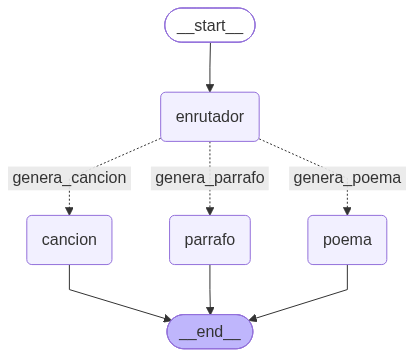

In [21]:
#workflow
routerWorkflowBuilder = StateGraph(State)

# Add nodes
routerWorkflowBuilder.add_node("parrafo", genera_parrafo)
routerWorkflowBuilder.add_node("poema", genera_poema)
routerWorkflowBuilder.add_node("cancion", genera_cancion)
routerWorkflowBuilder.add_node("enrutador", enrutador)

# Add edges to connect nodes
routerWorkflowBuilder.add_edge(START, "enrutador")
routerWorkflowBuilder.add_conditional_edges(
    "enrutador",
    route_decision,
    {  # Nombre obtenido por route_decision : Nombre del nodo a visitar
        "genera_parrafo": "parrafo",
        "genera_poema": "poema",
        "genera_cancion": "cancion",
    },
)
routerWorkflowBuilder.add_edge("parrafo", END)
routerWorkflowBuilder.add_edge("poema", END)
routerWorkflowBuilder.add_edge("cancion", END)

# Compile workflow
router_workflow = routerWorkflowBuilder.compile()

# Show the workflow
display(Image(router_workflow.get_graph().draw_mermaid_png()))

In [22]:
state = router_workflow.invoke({"input": "escribe una cancion sobre el caballero carmelo"})
print(state["output"])

Escribe la letra de una cancion
**Título: El Caballero Carmelo**

**Verso 1**  
En un pueblo lejano, bajo el sol radiante,  
Vivía un caballero, noble y constante.  
Carmelo su nombre, de corazón valiente,  
Con su espada en mano, siempre fue un referente.

**Coro**  
¡Oh, Caballero Carmelo!  
Con tu armadura brilla el cielo,  
Defendiendo a los débiles,  
Eres un héroe sin igual,  
En cada batalla, un ideal.

**Verso 2**  
Montado en su caballo, galopa veloz,  
Por los campos verdes, suena su voz.  
"Justicia y honor", es su lema eterno,  
Con su fiel escudero, siempre en el invierno.

**Coro**  
¡Oh, Caballero Carmelo!  
Con tu armadura brilla el cielo,  
Defendiendo a los débiles,  
Eres un héroe sin igual,  
En cada batalla, un ideal.

**Puente**  
Las leyendas cuentan de su gran valor,  
De cómo enfrentó al dragón con fervor.  
Con su espada de luz, cortó la oscuridad,  
Y trajo la paz a la humanidad.

**Verso 3**  
Las risas de los niños, su mayor tesoro,  
Carmelo sonríe, su cor

### Orquestador
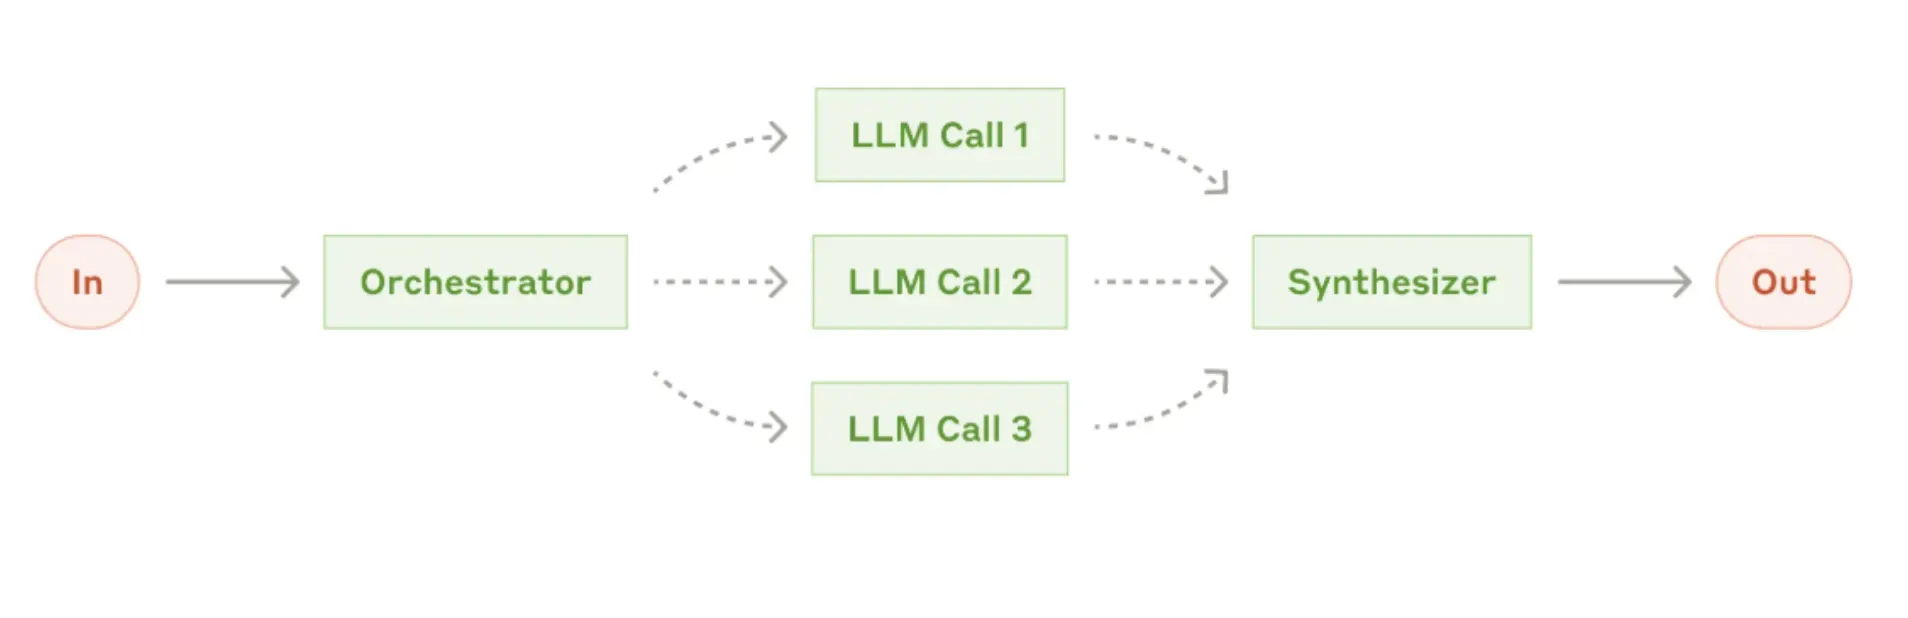
El orquestador desglosa una tarea y delega cada subtarea a los trabajadores.

- Por ejemplo, planificar un informe donde LLM puede determinar el número de secciones.

Ejemplo:

- Tomar un tema, planificar un informe por secciones y pedir a cada trabajador que escriba una sección.

In [24]:
from typing import Annotated, List
import operator

# Establecemos una estructura para la generacion de secciones del reporte
class Section(BaseModel):
    name: str = Field(
        description="Nombre de la seccion del reporte.",
    )
    description: str = Field(
        description="Una descripcion basica de temas y conceptos a ser cubiertos en esta seccion.",
    )

# Establecemos que un compendio se secciones es input para un reporte
class Sections(BaseModel):
    sections: List[Section] = Field(
        description="Secciones del reporte.",
    )

# LLM con structured output
planner = llm.with_structured_output(Sections)

In [26]:
# Graph state> administra el estado general recibido por el orquestador
class State(TypedDict):
    topic: str  # tema del reporte
    sections: list[Section]  # lista de secciones del reporte
    completed_sections: Annotated[
        list, operator.add
    ]  # todos los workers pueden ver y escribir a este item en paralelo
    final_report: str  # reporte final

# Worker state> administra estados internos de cada worker
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]

In [29]:
from langgraph.types import Send
# Nodos
def orchestrator(state: State):
    """Orquestador que genera el plan de elaboracion del reporte"""
    # Genera las peticiones de elaboracion de secciones en base a su plan
    report_sections = planner.invoke(
        [
            SystemMessage(content="Genera un plan para elaborar el reporte."),
            HumanMessage(content=f"Aqui el tema del reporte: {state['topic']}"),
        ]
    )
    return {"sections": report_sections.sections}


def worker(state: WorkerState):
    """Worker que escribe una seccion del reporte"""
    # Genera seccion objetivo
    section = llm.invoke(
        [
            SystemMessage(content="Escribe una seccion del reporte."),
            HumanMessage(
                content=f"Aqui esta el nombre de la seccion: {state['section'].name} y su descripcion: {state['section'].description}"
            ),
        ]
    )
    # Escribe el contenido de la seccion lograda en el item de estado de orquestador
    return {"completed_sections": [section.content]}


def synthesizer(state: State):
    """Sintetiza el reporte completo en base a las secciones"""
    # Lista de secciones completadas
    completed_sections = state["completed_sections"]
    # Fomartear seccion completada a str para usarla como contect para secciones finales
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}

# Condicional para crear workers por cada seccion del reporte
def assign_workers(state: State):
    """Asigna un worker a cada seccion en el plan"""
    # Ejecutamos la escritura en paralelo de workers en paralelo via Send() API
    return [Send("workers", {"section": s}) for s in state["sections"]]

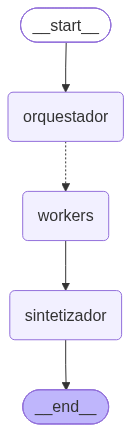

In [ ]:
# Build workflow
orchestrator_worker_builder = StateGraph(State)

# Add the nodes
orchestrator_worker_builder.add_node("orquestador", orchestrator)
orchestrator_worker_builder.add_node("workers", worker)
orchestrator_worker_builder.add_node("sintetizador", synthesizer)

# Add edges to connect nodes
orchestrator_worker_builder.add_edge(START, "orquestador")
orchestrator_worker_builder.add_conditional_edges(
    "orquestador", assign_workers, ["workers"]
)
orchestrator_worker_builder.add_edge("workers", "sintetizador")
orchestrator_worker_builder.add_edge("sintetizador", END)

# Compile the workflow
orchestrator_worker = orchestrator_worker_builder.compile()

# Show the workflow
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

In [32]:
state = orchestrator_worker.invoke({"topic": "Crea un reporte sobre reglas de escalabilidad de LLMs"})
from IPython.display import Markdown

Markdown(state["final_report"])

### Introducción a los LLMs y su descripción

Los Modelos de Lenguaje de Gran Escala (LLMs, por sus siglas en inglés) son sistemas de inteligencia artificial diseñados para comprender, generar y manipular texto en lenguaje natural. Estos modelos se basan en arquitecturas de aprendizaje profundo, particularmente en redes neuronales transformadoras, que les permiten procesar grandes volúmenes de datos textuales y aprender patrones complejos en el lenguaje. 

La importancia de los LLMs en el campo del procesamiento del lenguaje natural (NLP) radica en su capacidad para realizar tareas que van desde la traducción automática y la generación de texto hasta la respuesta a preguntas y el análisis de sentimientos. Su versatilidad y eficacia han revolucionado la forma en que interactuamos con la tecnología, facilitando la creación de aplicaciones más intuitivas y eficientes que pueden entender y responder a las necesidades humanas de manera más natural.

En los últimos años, la evolución de los LLMs ha sido notable. Desde los primeros modelos como Word2Vec y GloVe, que se centraban en la representación de palabras, hasta los modelos más avanzados como GPT-3 y BERT, que utilizan millones de parámetros y se entrenan en vastos conjuntos de datos, hemos visto un aumento exponencial en su capacidad y rendimiento. Esta evolución ha sido impulsada por el crecimiento en la disponibilidad de datos, el aumento en la potencia computacional y los avances en algoritmos de aprendizaje automático. Como resultado, los LLMs han alcanzado niveles de precisión y fluidez que antes se consideraban inalcanzables, abriendo nuevas posibilidades en la interacción humano-computadora y en la automatización de tareas lingüísticas complejas. 

En resumen, los LLMs representan un hito significativo en el desarrollo de la inteligencia artificial y el procesamiento del lenguaje natural, y su continuo avance promete transformar aún más nuestra relación con la tecnología en el futuro.

---

## Fundamentos de la Escalabilidad

La escalabilidad es un concepto fundamental en el diseño y la implementación de sistemas de inteligencia artificial (IA), ya que determina la capacidad de un sistema para manejar un aumento en la carga de trabajo o en el volumen de datos sin comprometer su rendimiento. En este contexto, es esencial comprender los dos enfoques principales de escalabilidad: la escalabilidad vertical y la escalabilidad horizontal.

### Escalabilidad Vertical

La escalabilidad vertical, también conocida como "escalado hacia arriba", implica aumentar la capacidad de un único nodo o servidor en un sistema. Esto se logra mediante la adición de recursos, como más memoria RAM, procesadores más potentes o almacenamiento adicional. Este enfoque es relativamente sencillo de implementar, ya que no requiere cambios significativos en la arquitectura del sistema. Sin embargo, tiene limitaciones inherentes, ya que cada servidor tiene un límite físico en cuanto a la cantidad de recursos que se le pueden añadir. Además, la dependencia de un solo nodo puede generar un punto único de fallo, lo que puede afectar la disponibilidad y la resiliencia del sistema.

### Escalabilidad Horizontal

Por otro lado, la escalabilidad horizontal, o "escalado hacia afuera", implica la adición de más nodos o servidores al sistema para distribuir la carga de trabajo. Este enfoque permite que un sistema crezca de manera más flexible y eficiente, ya que se pueden agregar o eliminar nodos según sea necesario. La escalabilidad horizontal es especialmente beneficiosa en entornos de IA donde se manejan grandes volúmenes de datos y se requieren capacidades de procesamiento intensivas. Sin embargo, este enfoque puede ser más complejo de implementar, ya que requiere una arquitectura distribuida y mecanismos de coordinación para garantizar que los nodos trabajen de manera efectiva juntos.

### Comparación y Consideraciones

La elección entre escalabilidad vertical y horizontal depende de varios factores, incluyendo el tipo de aplicación, el presupuesto y los requisitos de rendimiento. Mientras que la escalabilidad vertical puede ser adecuada para aplicaciones más pequeñas o menos críticas, la escalabilidad horizontal es generalmente preferida para sistemas de IA que requieren un alto rendimiento y disponibilidad. Además, en el contexto de la nube, muchas soluciones modernas están diseñadas para aprovechar la escalabilidad horizontal, permitiendo a las organizaciones adaptarse rápidamente a las demandas cambiantes del mercado.

En resumen, entender los fundamentos de la escalabilidad es crucial para el desarrollo de sistemas de inteligencia artificial robustos y eficientes. La elección entre escalabilidad vertical y horizontal debe basarse en un análisis cuidadoso de las necesidades específicas del sistema y las metas a largo plazo de la organización.

---

### Reglas de Escalabilidad para LLMs

La escalabilidad de los Modelos de Lenguaje de Gran Escala (LLMs, por sus siglas en inglés) es un aspecto crítico para garantizar su rendimiento y eficiencia en aplicaciones del mundo real. A continuación, se presentan las principales reglas y principios que deben seguirse para escalar LLMs de manera efectiva, optimizando recursos y gestionando datos de forma adecuada.

#### 1. Optimización de Recursos Computacionales
- **Uso Eficiente de Hardware**: Es fundamental seleccionar la infraestructura adecuada, que puede incluir GPUs, TPUs o clusters de servidores, para maximizar el rendimiento del modelo. La utilización de técnicas como la paralelización y la distribución de cargas de trabajo puede mejorar significativamente la eficiencia.
- **Ajuste de Hiperparámetros**: La optimización de hiperparámetros, como la tasa de aprendizaje y el tamaño del batch, es esencial para mejorar la convergencia del modelo y reducir el tiempo de entrenamiento. Herramientas automatizadas de ajuste pueden ser útiles en este proceso.

#### 2. Gestión de Datos
- **Curación y Preprocesamiento de Datos**: La calidad de los datos de entrenamiento es crucial. Implementar procesos de curación y preprocesamiento que eliminen ruido y sesgos puede resultar en un modelo más robusto y generalizable.
- **Almacenamiento y Acceso a Datos**: Utilizar sistemas de almacenamiento escalables y eficientes que permitan un acceso rápido a grandes volúmenes de datos es vital. Las bases de datos distribuidas y el uso de formatos de datos optimizados pueden facilitar este acceso.

#### 3. Estrategias de Entrenamiento
- **Entrenamiento Incremental**: En lugar de entrenar un modelo desde cero, se puede optar por un enfoque de entrenamiento incremental, donde se aprovechan modelos preentrenados y se ajustan a tareas específicas. Esto no solo ahorra tiempo, sino que también reduce la necesidad de grandes cantidades de datos.
- **Regularización y Técnicas de Dropout**: Implementar técnicas de regularización ayuda a prevenir el sobreajuste, lo que es especialmente importante cuando se trabaja con conjuntos de datos limitados. El uso de dropout y otras técnicas puede mejorar la generalización del modelo.

#### 4. Monitoreo y Mantenimiento
- **Monitoreo Continuo del Rendimiento**: Establecer métricas claras para evaluar el rendimiento del modelo en producción es esencial. El monitoreo continuo permite detectar desviaciones y ajustar el modelo según sea necesario.
- **Actualización y Reentrenamiento**: Los LLMs deben ser actualizados regularmente con nuevos datos para mantener su relevancia y precisión. Establecer un ciclo de reentrenamiento programado puede ayudar a mantener el modelo alineado con las tendencias actuales.

#### 5. Consideraciones Éticas y de Seguridad
- **Transparencia y Explicabilidad**: A medida que se escalan los LLMs, es importante garantizar que los procesos sean transparentes y que las decisiones del modelo sean explicables. Esto es crucial para la confianza del usuario y la aceptación del modelo.
- **Seguridad de los Datos**: Implementar medidas de seguridad robustas para proteger los datos utilizados en el entrenamiento y la inferencia es fundamental, especialmente en aplicaciones sensibles.

Al seguir estas reglas y principios, se puede lograr una escalabilidad efectiva de los LLMs, maximizando su rendimiento y asegurando su aplicabilidad en diversas áreas. La combinación de optimización de recursos, gestión adecuada de datos y un enfoque ético garantizará que los LLMs sigan siendo herramientas valiosas en el futuro.

---

### Desafíos en la Escalabilidad de LLMs

La escalabilidad de los Modelos de Lenguaje de Gran Tamaño (LLMs, por sus siglas en inglés) representa un reto significativo en el ámbito de la inteligencia artificial. A medida que estos modelos se vuelven más complejos y se entrenan con volúmenes de datos cada vez mayores, surgen varios desafíos que pueden afectar su rendimiento y viabilidad en aplicaciones del mundo real. A continuación, se analizan los principales desafíos asociados con la escalabilidad de los LLMs: la latencia, el costo computacional y la calidad de los datos.

#### Latencia

La latencia se refiere al tiempo que tarda un modelo en procesar una entrada y generar una respuesta. A medida que los LLMs aumentan en tamaño y complejidad, la latencia puede incrementarse de manera significativa. Esto es especialmente problemático en aplicaciones en tiempo real, como asistentes virtuales o sistemas de atención al cliente, donde las respuestas rápidas son cruciales. La optimización de la latencia requiere un equilibrio entre la complejidad del modelo y la velocidad de procesamiento, lo que puede limitar la capacidad de los desarrolladores para implementar modelos más avanzados.

#### Costo Computacional

El costo computacional es otro desafío importante en la escalabilidad de los LLMs. Entrenar y desplegar modelos de gran tamaño requiere recursos computacionales significativos, incluyendo potentes unidades de procesamiento gráfico (GPUs) y grandes cantidades de memoria. Esto no solo implica un alto costo económico, sino que también plantea preocupaciones sobre la sostenibilidad ambiental, dado el consumo energético asociado con el entrenamiento de estos modelos. Las organizaciones deben considerar cuidadosamente su infraestructura y presupuesto al escalar LLMs, lo que puede limitar la accesibilidad de estas tecnologías a empresas más pequeñas o con menos recursos.

#### Calidad de los Datos

La calidad de los datos utilizados para entrenar LLMs es fundamental para su rendimiento. A medida que se escalan los modelos, la cantidad de datos necesarios para el entrenamiento también aumenta, lo que puede llevar a la inclusión de datos de menor calidad o sesgados. Esto puede resultar en modelos que no solo son menos efectivos, sino que también pueden perpetuar o amplificar sesgos existentes en los datos. Asegurar la calidad y la diversidad de los datos es un desafío crítico que debe abordarse para garantizar que los LLMs sean justos y representativos.

En conclusión, la escalabilidad de los LLMs enfrenta desafíos significativos que deben ser considerados cuidadosamente por los investigadores y desarrolladores. La latencia, el costo computacional y la calidad de los datos son factores interrelacionados que pueden influir en la efectividad y la implementación de estos modelos en diversas aplicaciones. Abordar estos desafíos es esencial para avanzar en el desarrollo de LLMs más robustos y accesibles.

---

### Casos de Estudio y su Descripción

En esta sección, se presentan ejemplos de implementaciones exitosas de escalabilidad en Modelos de Lenguaje de Gran Tamaño (LLMs, por sus siglas en inglés). Estos casos ilustran las estrategias adoptadas por diversas organizaciones para mejorar la eficiencia, la capacidad de respuesta y la adaptabilidad de sus modelos, así como los resultados tangibles que han logrado.

#### Caso de Estudio 1: OpenAI y GPT-3

**Descripción:** OpenAI lanzó GPT-3, un modelo de lenguaje con 175 mil millones de parámetros, que ha demostrado ser altamente efectivo en una variedad de tareas de procesamiento del lenguaje natural. 

**Estrategias Utilizadas:**
- **Optimización de la arquitectura:** Se implementaron técnicas avanzadas de optimización, como la atención escalable, que permite al modelo manejar contextos más largos sin un aumento proporcional en el costo computacional.
- **Uso de infraestructura en la nube:** OpenAI aprovechó la infraestructura en la nube para escalar horizontalmente, permitiendo el acceso a recursos computacionales bajo demanda.

**Resultados Obtenidos:**
- **Mejora en la calidad de las respuestas:** GPT-3 ha mostrado un rendimiento superior en tareas de generación de texto, completando frases y respondiendo preguntas con un nivel de coherencia y creatividad sin precedentes.
- **Adopción en diversas industrias:** La implementación de GPT-3 ha permitido a empresas en sectores como la educación, la atención al cliente y el entretenimiento, mejorar sus servicios y ofrecer experiencias personalizadas a los usuarios.

#### Caso de Estudio 2: Google y BERT

**Descripción:** Google desarrolló BERT (Bidirectional Encoder Representations from Transformers), un modelo que revolucionó la búsqueda semántica al comprender el contexto de las palabras en las oraciones.

**Estrategias Utilizadas:**
- **Entrenamiento en múltiples idiomas:** BERT fue entrenado en un corpus multilingüe, lo que permitió su escalabilidad a diferentes lenguas y dialectos, aumentando su aplicabilidad global.
- **Fine-tuning específico:** Se implementó un enfoque de fine-tuning que permite adaptar el modelo a tareas específicas con un conjunto de datos relativamente pequeño, optimizando así el uso de recursos.

**Resultados Obtenidos:**
- **Mejoras en la búsqueda:** La implementación de BERT en el motor de búsqueda de Google resultó en una mejora significativa en la relevancia de los resultados, lo que llevó a una mayor satisfacción del usuario.
- **Impacto en la industria:** BERT ha sido adoptado por numerosas empresas para mejorar sus sistemas de atención al cliente y análisis de sentimientos, demostrando su versatilidad y efectividad.

#### Caso de Estudio 3: Facebook y RoBERTa

**Descripción:** Facebook AI desarrolló RoBERTa, una variante de BERT que optimiza el entrenamiento y mejora el rendimiento en tareas de comprensión del lenguaje.

**Estrategias Utilizadas:**
- **Ajuste de hiperparámetros:** RoBERTa se entrenó con un conjunto de hiperparámetros ajustados para maximizar el rendimiento, incluyendo el uso de más datos y un mayor número de pasos de entrenamiento.
- **Eliminación de tareas de preentrenamiento:** A diferencia de BERT, RoBERTa eliminó algunas tareas de preentrenamiento para centrarse en el aprendizaje de representaciones más robustas.

**Resultados Obtenidos:**
- **Rendimiento superior en benchmarks:** RoBERTa ha superado a su predecesor en múltiples benchmarks de procesamiento del lenguaje, estableciendo nuevos estándares en la industria.
- **Adopción en aplicaciones comerciales:** Su implementación ha permitido a empresas mejorar sus capacidades de análisis de texto y procesamiento de lenguaje natural, facilitando la automatización de tareas complejas.

Estos casos de estudio demuestran cómo la escalabilidad en LLMs no solo mejora el rendimiento de los modelos, sino que también permite a las organizaciones innovar y ofrecer soluciones más efectivas en un entorno cada vez más competitivo.

---

### Conclusiones y Recomendaciones

En el presente reporte se han analizado diversos aspectos relacionados con la escalabilidad de los Modelos de Lenguaje de Gran Tamaño (LLMs, por sus siglas en inglés). A través de un enfoque exhaustivo, se han identificado los principales hallazgos que subrayan la importancia de establecer reglas claras y efectivas para la implementación de estos modelos en proyectos futuros.

**Hallazgos Clave:**

1. **Eficiencia en el Uso de Recursos:** Se ha observado que la escalabilidad de los LLMs está intrínsecamente ligada a la eficiencia en el uso de recursos computacionales. Los modelos que optimizan su arquitectura y algoritmos de entrenamiento tienden a ofrecer un mejor rendimiento en entornos de producción.

2. **Adaptabilidad a Diferentes Contextos:** Los LLMs deben ser adaptables a diversas aplicaciones y dominios. La personalización de modelos según el contexto específico de uso no solo mejora la relevancia de las respuestas, sino que también contribuye a una utilización más efectiva de los recursos.

3. **Importancia de la Evaluación Continua:** La implementación de métricas de rendimiento y la evaluación continua son esenciales para garantizar que los modelos se mantengan relevantes y eficientes a lo largo del tiempo. Esto incluye la monitorización de la calidad de las respuestas y la capacidad de adaptación a nuevos datos.

4. **Ética y Responsabilidad:** La escalabilidad de los LLMs también plantea desafíos éticos significativos. Es fundamental establecer directrices que aseguren un uso responsable de la tecnología, minimizando sesgos y garantizando la transparencia en la toma de decisiones automatizadas.

**Recomendaciones:**

1. **Desarrollo de Protocolos de Escalabilidad:** Se recomienda la creación de protocolos estandarizados que guíen la implementación de LLMs en diferentes proyectos, asegurando que se consideren aspectos como la eficiencia, la adaptabilidad y la ética desde las etapas iniciales.

2. **Inversión en Capacitación:** Es crucial invertir en la capacitación del personal involucrado en el desarrollo y la implementación de LLMs. Esto incluye formación en técnicas de optimización, evaluación de modelos y consideraciones éticas.

3. **Fomento de la Colaboración Interdisciplinaria:** La escalabilidad de los LLMs se beneficiará de la colaboración entre diferentes disciplinas, incluyendo la informática, la lingüística, la psicología y la ética. Se sugiere establecer equipos multidisciplinarios para abordar los desafíos complejos asociados con estos modelos.

4. **Implementación de Sistemas de Feedback:** Se recomienda establecer sistemas de feedback que permitan a los usuarios reportar problemas y sugerencias sobre el rendimiento de los LLMs. Esto no solo mejorará la calidad del modelo, sino que también fomentará una relación más cercana entre los desarrolladores y los usuarios finales.

En conclusión, la escalabilidad de los LLMs es un aspecto crítico que debe ser abordado con seriedad y rigor. Las recomendaciones aquí presentadas buscan proporcionar un marco que facilite la implementación efectiva y responsable de estos modelos en proyectos futuros, asegurando que se maximicen sus beneficios mientras se mitigan los riesgos asociados.

### Evaluator-optimizer
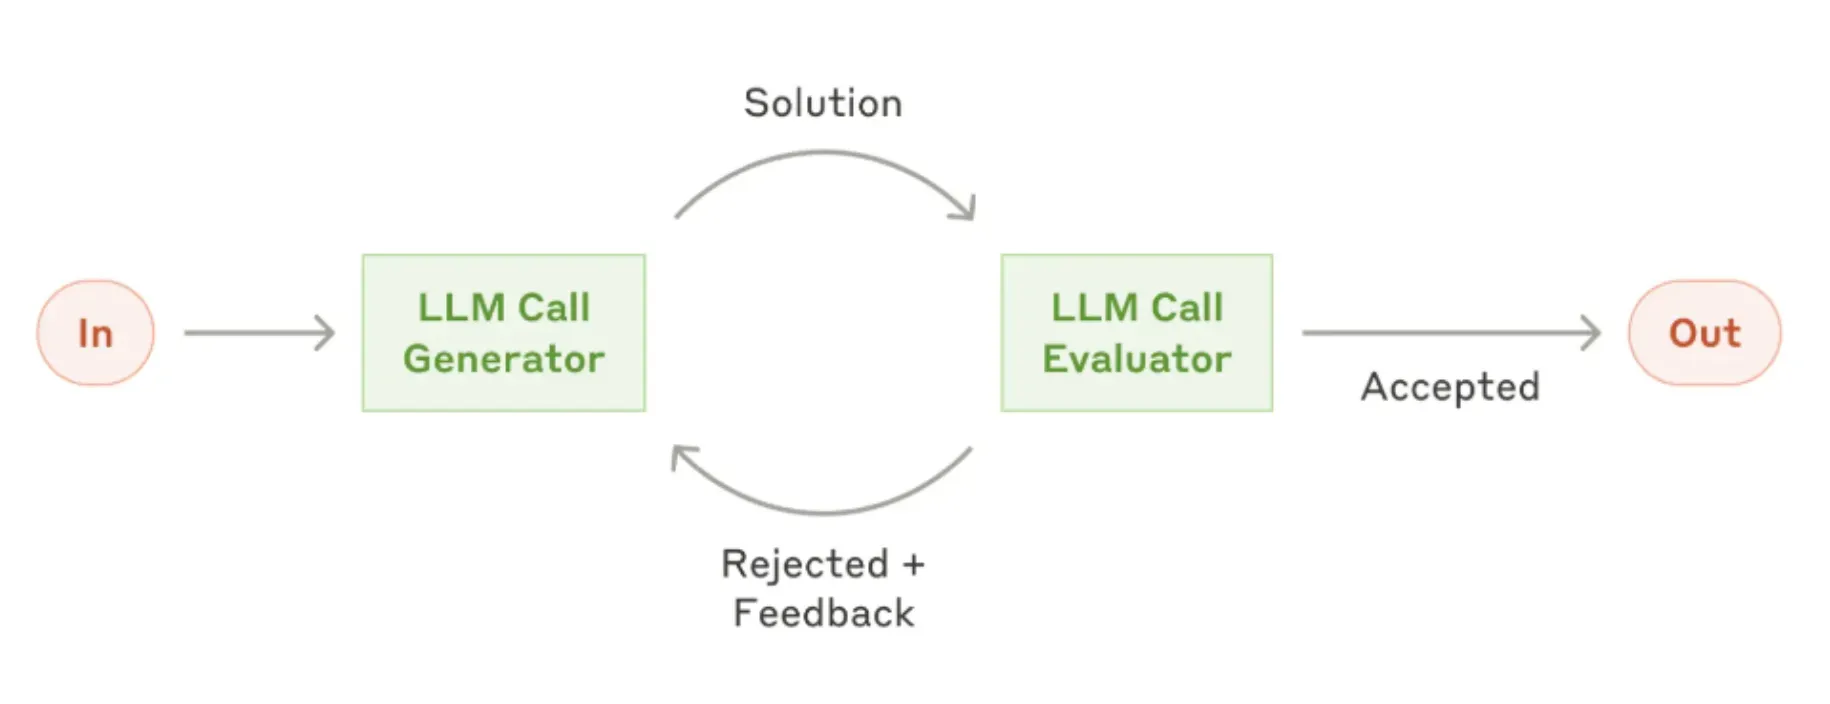
Una llamada LLM genera una respuesta, mientras que otra proporciona evaluación y retroalimentación en un bucle.

Por ejemplo, al evaluar la calidad de las respuestas de un sistema RAG (para alucinaciones).

In [33]:
# Schema for structured output to use in evaluation
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="Decide si una broma es graciosa o no.",
    )
    feedback: str = Field(
        description="Si es que no es graciosa, da feedback en como mejorarla.",
    )


# Augment the LLM with schema for structured output
evaluator = llm.with_structured_output(Feedback)

In [34]:
# Graph state
class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str

In [35]:
# Nodes
def llm_call_generator(state: State):
    """Genera una broma"""
    if state.get("feedback"):
        msg = llm.invoke(
            f"Escribe una broma sobre {state['topic']} pero considera el feedback: {state['feedback']}"
        )
    else:
        msg = llm.invoke(f"Escribe una broma sobre {state['topic']}")
    return {"joke": msg.content}


def llm_call_evaluator(state: State):
    """Evalua una broma generada"""
    grade = evaluator.invoke(f"Evalua la siguiente broma> {state['joke']}")
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}


# Conditional edge function to route back to joke generator or end based upon feedback from the evaluator
def route_joke(state: State):
    """Retorna hacia el generador de bromas o termina basado en feedback del evaluador"""

    if state["funny_or_not"] == "funny":
        return "Accepted"
    elif state["funny_or_not"] == "not funny":
        return "Rejected + Feedback"

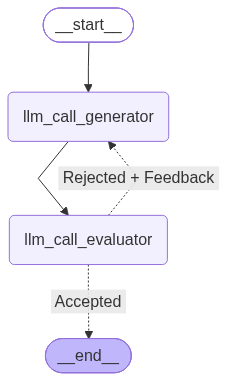

In [36]:
# Build workflow
optimizer_builder = StateGraph(State)

# Add the nodes
optimizer_builder.add_node("llm_call_generator", llm_call_generator)
optimizer_builder.add_node("llm_call_evaluator", llm_call_evaluator)

# Add edges to connect nodes
optimizer_builder.add_edge(START, "llm_call_generator")
optimizer_builder.add_edge("llm_call_generator", "llm_call_evaluator")
optimizer_builder.add_conditional_edges(
    "llm_call_evaluator",
    route_joke,
    {  # Name returned by route_joke : Name of next node to visit
        "Accepted": END,
        "Rejected + Feedback": "llm_call_generator",
    },
)

# Compile the workflow
optimizer_workflow = optimizer_builder.compile()

# Show the workflow
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

In [37]:
state = optimizer_workflow.invoke({"topic": "llms en un bar"})
print(state["joke"])

Un modelo de lenguaje entra a un bar y le dice al bartender: "¡Oye, ponme una cerveza!" 

El bartender responde: "¿Por qué debería hacerlo?"

El modelo de lenguaje dice: "Porque tengo un buen 'prompt' para ti: ¡una ronda para todos!"

El bartender se ríe y dice: "Está bien, pero solo si prometes no 'overfitear' la conversación." 

El modelo de lenguaje responde: "¡Trato hecho! Pero no me hagas 'fine-tune' en temas aburridos."


In [38]:
print(state["feedback"])

La broma es ingeniosa y juega bien con términos técnicos del aprendizaje automático, lo que puede resonar con quienes están familiarizados con el tema. La interacción entre el modelo de lenguaje y el bartender es divertida y mantiene un buen ritmo. ¡Sigue así!


In [39]:
print(state["funny_or_not"])

funny


### Agent
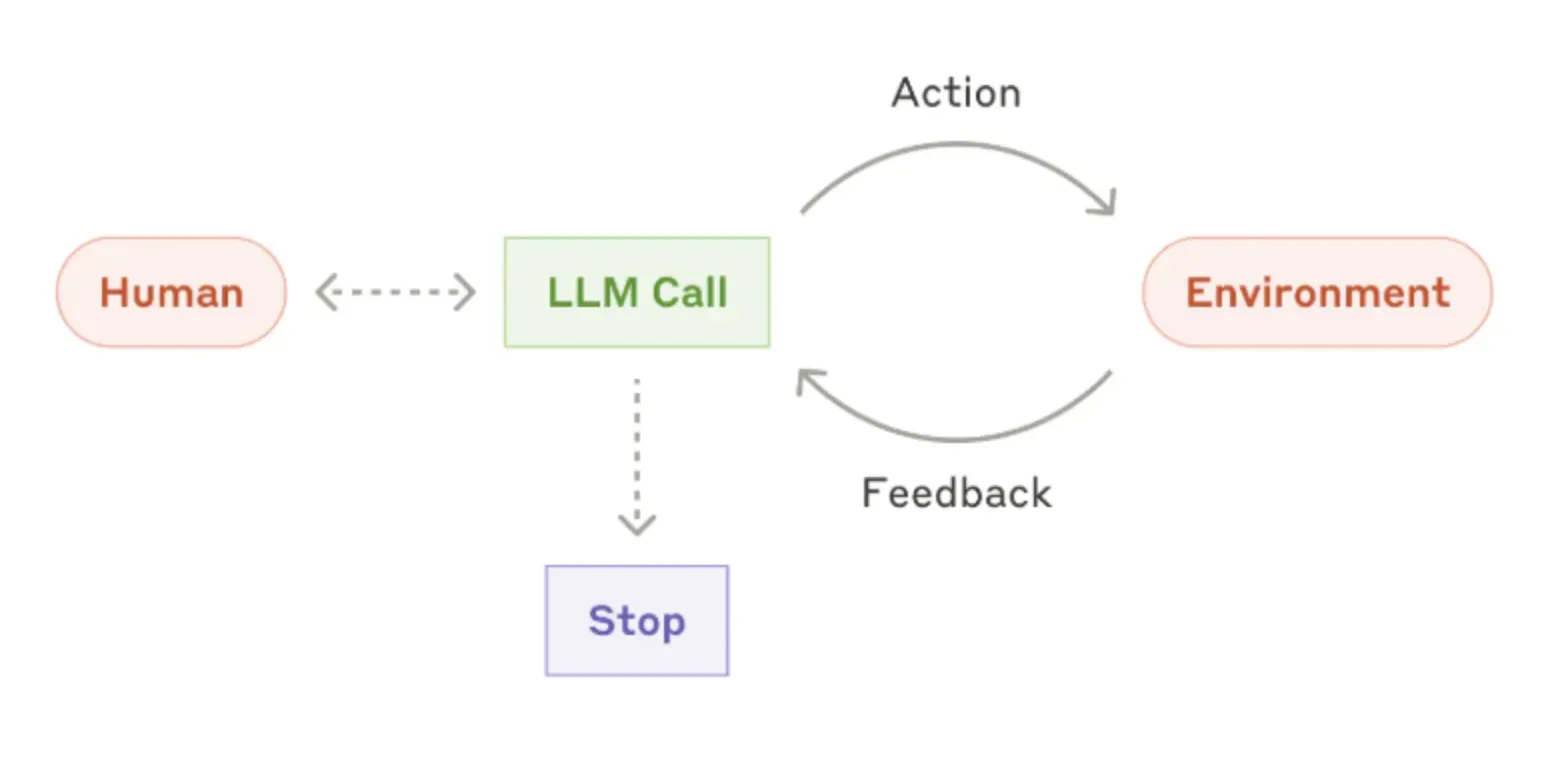
Los agentes planifican, toman medidas (mediante la llamada a herramientas) y responden a la retroalimentación (en un bucle).

Por ejemplo, al resolver problemas abiertos que no se pueden definir como un flujo de trabajo.

In [40]:
from langchain_core.tools import tool

@tool
def multiplicar(a: int, b: int) -> int:
    """multiplicar a * b.
    Args:
        a: first int
        b: second int
    """
    return a * b

@tool
def sumar(a: int, b: int) -> int:
    """sumar a + b.
    Args:
        a: first int
        b: second int
    """
    return a + b

@tool
def dividir(a: int, b: int) -> float:
    """Dividir a / b.
    Args:
        a: first int
        b: second int
    """
    return a / b

@tool
def substraer(a: int, b: int) -> int:
    """Dividir a - b.
    Args:
        a: first int
        b: second int
    """
    return a - b


# Augment the LLM with tools
tools = [sumar, multiplicar, dividir, substraer]
tools_by_name = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(tools)

In [41]:
from langgraph.graph import MessagesState
from langchain_core.messages import ToolMessage

# nodos del agente en langgraph
def llm_call(state: MessagesState):
    """LLM decide si invocar a herramienta o no"""
    return {
        "messages": [
            llm_with_tools.invoke(
                [
                    SystemMessage(
                        content="Eres un asistente útil encargado de realizar cálculos aritméticos en un conjunto de entradas."
                    )
                ]
                + state["messages"]
            )
        ]
    }


def tool_node(state: dict):
    """Ejecuta la invocacion a una herramienta"""
    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}


# Función Condicional para enrutar al nodo de TOOL o al estado END según resultado
# Solamente puede devolver uno de estos dos valores, environment o END. 
def should_continue(state: MessagesState) -> Literal["environment", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]
    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "Action"
    # Otherwise, we stop (reply to the user)
    return END

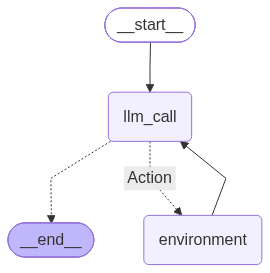

In [42]:
# workflow
agent_builder = StateGraph(MessagesState)

# Agrega nodos
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("environment", tool_node)

# Agrega vertices para conectar nodos
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        # Nombre retornado por "should_continue" : Nombre del nodo a visitar
        "Action": "environment",
        END: END,
    },
)
agent_builder.add_edge("environment", "llm_call")

# Compilar agent
agent = agent_builder.compile()

# Mostrar Agente
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [44]:
messages = [HumanMessage(content="Suma 3 más 4. Luego, multiplica el resultado por 4.")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Suma 3 más 4. Luego, multiplica el resultado por 4.
================================== Ai Message ==================================
Tool Calls:
  sumar (call_i95UaCGi9PZh0VeZEb8IxOJB)
 Call ID: call_i95UaCGi9PZh0VeZEb8IxOJB
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
================================== Ai Message ==================================
Tool Calls:
  multiplicar (call_xmKuiDooQKS9LIywtD5coHMg)
 Call ID: call_xmKuiDooQKS9LIywtD5coHMg
  Args:
    a: 7
    b: 4
================================= Tool Message =================================

28
================================== Ai Message ==================================

La suma de 3 más 4 es 7, y al multiplicar ese resultado por 4, obtenemos 28.
